In [11]:
import os
import random
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

warnings.filterwarnings("ignore")

print(tf.__version__)

2.21.0


In [12]:
DATASET_PATH = "Pemandangan Alam"

TRAIN_DIR = os.path.join(
    DATASET_PATH,
    "seg_train",
    "seg_train"
)

TEST_DIR = os.path.join(
    DATASET_PATH,
    "seg_test",
    "seg_test"
)

PRED_DIR = os.path.join(
    DATASET_PATH,
    "seg_pred",
    "seg_pred"
)

IMG_SIZE = (299, 299)

BATCH_SIZE = 16

EPOCHS = 10

In [13]:
print("Train :", TRAIN_DIR)
print("Test  :", TEST_DIR)
print("Pred  :", PRED_DIR)

print("\nIsi Train:")
print(os.listdir(TRAIN_DIR))

print("\nIsi Test:")
print(os.listdir(TEST_DIR))

Train : Pemandangan Alam\seg_train\seg_train
Test  : Pemandangan Alam\seg_test\seg_test
Pred  : Pemandangan Alam\seg_pred\seg_pred

Isi Train:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Isi Test:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [14]:
classes = sorted([
    folder
    for folder in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, folder))
])

print("=" * 40)
print("Jumlah kelas :", len(classes))
print("=" * 40)

for cls in classes:
    total = len([
        f for f in os.listdir(os.path.join(TRAIN_DIR, cls))
        if os.path.isfile(os.path.join(TRAIN_DIR, cls, f))
    ])
    print(f"{cls:<12} : {total}")

Jumlah kelas : 6
buildings    : 2191
forest       : 2271
glacier      : 2404
mountain     : 2512
sea          : 2274
street       : 2382


In [15]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


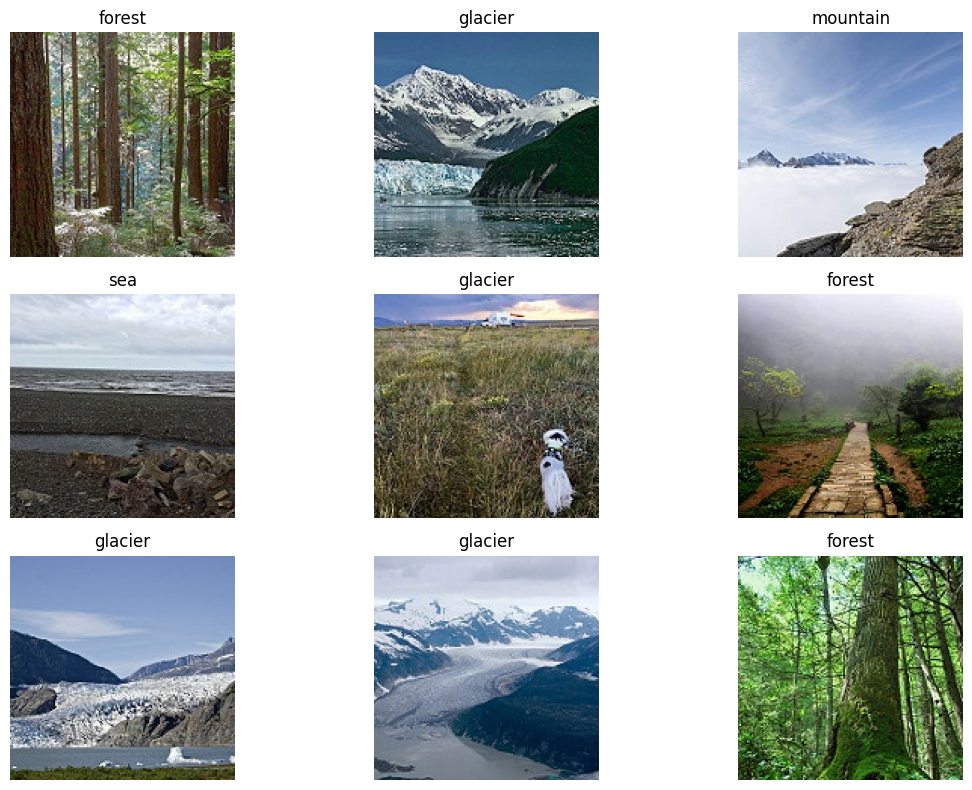

In [16]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    img = (images[i]+1)/2

    plt.imshow(img)

    plt.title(
        list(train_generator.class_indices.keys())[np.argmax(labels[i])]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(299,299,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

outputs = Dense(
    train_generator.num_classes,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 74, 74,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add_12[0][0]    

 Total params: 21,387,566 (81.59 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [18]:
callbacks = [

    EarlyStopping(
        patience=3,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        factor=0.2,
        patience=2
    ),

    ModelCheckpoint(
        "best_xception.keras",
        save_best_only=True
    )

]

In [19]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
702/702 ━━━━━━━━━━━━━━━━━━━━ 1901s 3s/step - accuracy: 0.8793 - loss: 0.3254 - val_accuracy: 0.9058 - val_loss: 0.2394 - learning_rate: 0.0010
Epoch 2/5
702/702 ━━━━━━━━━━━━━━━━━━━━ 1881s 3s/step - accuracy: 0.9064 - loss: 0.2440 - val_accuracy: 0.9112 - val_loss: 0.2388 - learning_rate: 0.0010
Epoch 3/5
702/702 ━━━━━━━━━━━━━━━━━━━━ 1874s 3s/step - accuracy: 0.9175 - loss: 0.2223 - val_accuracy: 0.9130 - val_loss: 0.2195 - learning_rate: 0.0010
Epoch 4/5
702/702 ━━━━━━━━━━━━━━━━━━━━ 1875s 3s/step - accuracy: 0.9248 - loss: 0.2011 - val_accuracy: 0.9215 - val_loss: 0.2189 - learning_rate: 0.0010
Epoch 5/5
702/702 ━━━━━━━━━━━━━━━━━━━━ 1871s 3s/step - accuracy: 0.9297 - loss: 0.1853 - val_accuracy: 0.9212 - val_loss: 0.2227 - learning_rate: 0.0010


In [20]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
702/702 ━━━━━━━━━━━━━━━━━━━━ 2657s 4s/step - accuracy: 0.8970 - loss: 0.2985 - val_accuracy: 0.9233 - val_loss: 0.2188 - learning_rate: 1.0000e-05
Epoch 2/5
702/702 ━━━━━━━━━━━━━━━━━━━━ 2618s 4s/step - accuracy: 0.9267 - loss: 0.1980 - val_accuracy: 0.9269 - val_loss: 0.2081 - learning_rate: 1.0000e-05
Epoch 3/5
702/702 ━━━━━━━━━━━━━━━━━━━━ 2686s 4s/step - accuracy: 0.9382 - loss: 0.1699 - val_accuracy: 0.9312 - val_loss: 0.2003 - learning_rate: 1.0000e-05
Epoch 4/5
702/702 ━━━━━━━━━━━━━━━━━━━━ 2666s 4s/step - accuracy: 0.9467 - loss: 0.1468 - val_accuracy: 0.9290 - val_loss: 0.2004 - learning_rate: 1.0000e-05
Epoch 5/5
702/702 ━━━━━━━━━━━━━━━━━━━━ 2686s 4s/step - accuracy: 0.9542 - loss: 0.1283 - val_accuracy: 0.9326 - val_loss: 0.2001 - learning_rate: 1.0000e-05


In [21]:
loss, accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print("=" * 40)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy * 100:.2f}%")
print("=" * 40)

188/188 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.9340 - loss: 0.1852
Test Loss     : 0.1852
Test Accuracy : 93.40%


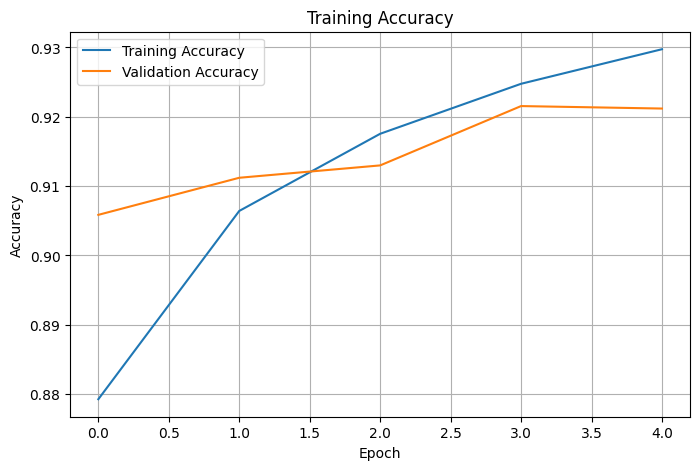

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.legend()

plt.grid()

plt.show()

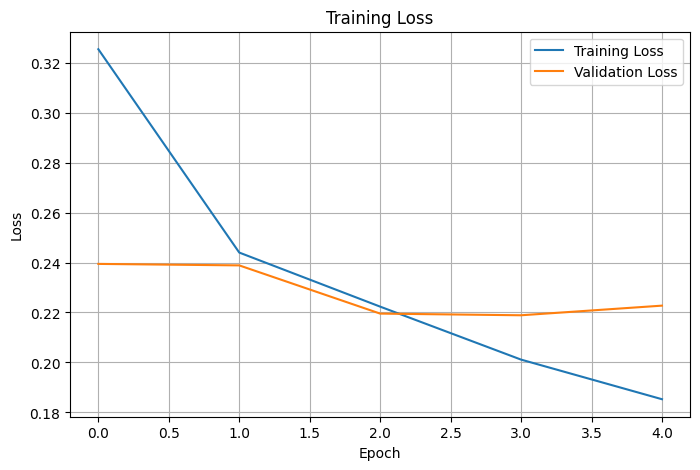

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.grid()

plt.show()

In [24]:
test_generator.reset()

predictions = model.predict(
    test_generator,
    verbose=1
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = test_generator.classes

class_names = list(
    test_generator.class_indices.keys()
)

188/188 ━━━━━━━━━━━━━━━━━━━━ 422s 2s/step


In [25]:
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   buildings       0.93      0.94      0.93       437
      forest       0.99      0.99      0.99       474
     glacier       0.90      0.87      0.88       553
    mountain       0.89      0.88      0.88       525
         sea       0.96      0.99      0.98       510
      street       0.94      0.94      0.94       501

    accuracy                           0.93      3000
   macro avg       0.93      0.94      0.94      3000
weighted avg       0.93      0.93      0.93      3000



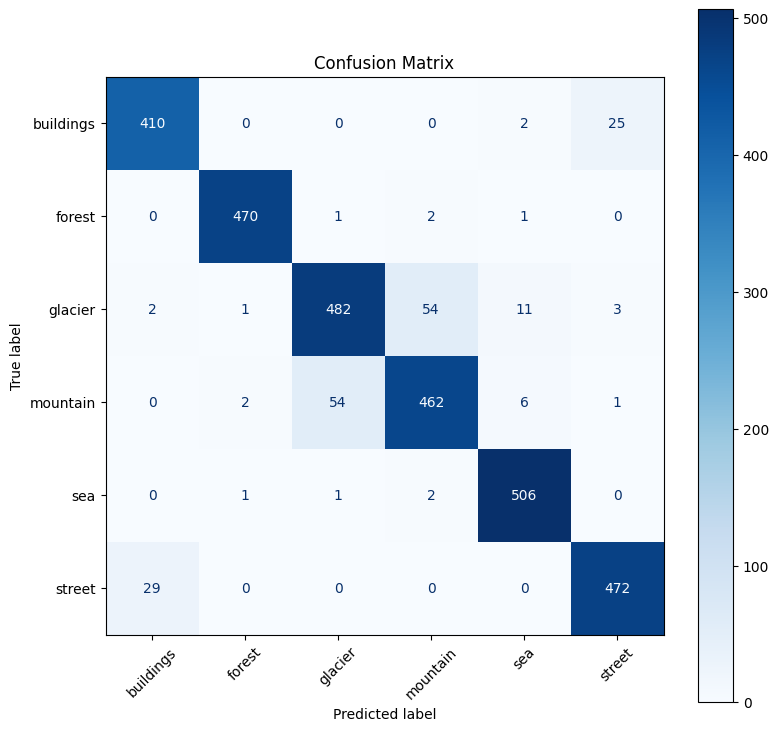

In [26]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9,9))

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix")

plt.show()

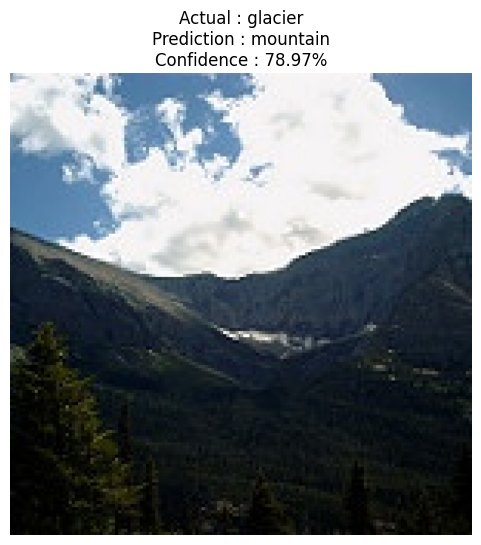

In [27]:
import random

idx = random.randint(
    0,
    len(test_generator.filepaths)-1
)

img_path = test_generator.filepaths[idx]

img = tf.keras.utils.load_img(
    img_path,
    target_size=(299,299)
)

img_array = tf.keras.utils.img_to_array(img)

input_img = np.expand_dims(
    img_array,
    axis=0
)

input_img = preprocess_input(input_img)

prediction = model.predict(
    input_img,
    verbose=0
)

predicted = class_names[
    np.argmax(prediction)
]

confidence = np.max(prediction)*100

actual = img_path.split(os.sep)[-2]

plt.figure(figsize=(6,6))

plt.imshow(img)

plt.axis("off")

plt.title(
    f"Actual : {actual}\nPrediction : {predicted}\nConfidence : {confidence:.2f}%"
)

plt.show()

In [28]:
model = tf.keras.models.load_model("best_xception.keras")

model.save("xception_scene.keras")

print("Model berhasil disimpan.")

Model berhasil disimpan.
